# Expiry Risk Model — RandomForest + Calibration

**Algorithm**: `RandomForestClassifier` + `CalibratedClassifierCV`

**Dataset**: Synthetic batches from `data/pharma_sales_data/salesdaily.csv`

**CRITICAL settings — never change:**
- `class_weight='balanced'` — expiry events are <5% of real batches
- `CalibratedClassifierCV(method='isotonic')` — spec-locked, raw RF probabilities are overconfident

**Pass criteria**: AUC > 0.80, Recall >= 0.85 at optimal threshold

**Output**: `expiry_risk` + `expiry_risk_threshold` saved via `ModelStore`

**Label**: batch expired with remaining stock (`quantity_remaining > 0` at `expiry_date`).
Label is NOT derived from any feature — label synthesis and feature engineering
are separated so there is no data leakage.

**Cold start note**: This global model is trained on synthetic labels.
AUC=1.0 on synthetic data is expected and blocks the save.
Real model activates at 180 days + 50 expired-batch labels per client.
Until then: `compute_liquidation_date()` formula fallback from `expiry_features.py`.

## 1 — Imports & Config

In [21]:
import sys, os
from pathlib import Path

# Ensure project repo root is on sys.path so `ml` imports resolve
ROOT_CANDIDATE = Path(r'C:\Users\KIIT0001\Desktop\DL PROJECTS\FlowSync\FlowSync-ML-and-Agents').resolve()
if ROOT_CANDIDATE.exists():
    REPO_ROOT = ROOT_CANDIDATE
else:
    REPO_ROOT = Path.cwd().resolve()
    while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'data').exists():
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import TimeSeriesSplit

from ml.features.expiry_features import build_expiry_features, FEATURE_COLS
from ml.registry.model_store import ModelStore
from ml.shared.config_loader import _defaults

cfg           = _defaults()
AUC_TARGET    = cfg['auc_target']       # 0.80
RECALL_TARGET = cfg['recall_target']    # 0.85
RF_CFG        = cfg['random_forest']
DATA_DIR      = str((REPO_ROOT / 'data').resolve())

# class_weight='balanced' is SPEC-MANDATED — never remove
RF_PARAMS = {
    'n_estimators':     RF_CFG.get('n_estimators',     300),
    'max_depth':        RF_CFG.get('max_depth',        8),
    'class_weight':     'balanced',   # CRITICAL — expiry events <5% of real batches
    'min_samples_leaf': RF_CFG.get('min_samples_leaf', 5),
    'random_state':     RF_CFG.get('random_state',     42),
    'n_jobs':           -1,
}

print(f'AUC target    : {AUC_TARGET}')
print(f'Recall target : {RECALL_TARGET}')
print(f'class_weight  : {RF_PARAMS["class_weight"]}  <- spec-mandated, never remove')
print(f'REPO_ROOT     : {REPO_ROOT}')
print('Imports OK')

AUC target    : 0.8
Recall target : 0.85
class_weight  : balanced  <- spec-mandated, never remove
REPO_ROOT     : C:\Users\KIIT0001\Desktop\DL PROJECTS\FlowSync\FlowSync-ML-and-Agents
Imports OK


## 2 — Load Pharma Sales Dataset

**Path**: `data/pharma_sales_data/salesdaily.csv` — per `ml-rules.md` dataset paths.
Note: folder is `pharma_sales_data`, not `pharma_sales`.

In [22]:
# FIX 1: correct path per ml-rules.md — pharma_sales_data, not pharma_sales
sales_path = os.path.join(DATA_DIR, 'pharma_sales_data', 'salesdaily.csv')
print(f"[{'OK' if os.path.exists(sales_path) else 'MISSING'}] {sales_path}")
assert os.path.exists(sales_path), (
    f'salesdaily.csv not found at {sales_path}\n'
    f'Download from https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data'
)

sales = pd.read_csv(sales_path)
for dc in ['datum', 'date', 'Date']:
    if dc in sales.columns:
        sales[dc] = pd.to_datetime(sales[dc], dayfirst=True, errors='coerce')
        sales.rename(columns={dc: 'datum'}, inplace=True)
        break

drug_cols = [
    c for c in sales.columns
    if sales[c].dtype in ['float64', 'int64']
    and c not in ['Year', 'M', 'D', 'Month', 'Hour', 'Weekday', 'Weekend']
]
print(f'Rows: {len(sales):,}  |  Drug columns ({len(drug_cols)}): {drug_cols}')
sales.head(3)

[OK] C:\Users\KIIT0001\Desktop\DL PROJECTS\FlowSync\FlowSync-ML-and-Agents\data\pharma_sales_data\salesdaily.csv
Rows: 2,106  |  Drug columns (8): ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-02-01,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-03-01,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-04-01,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday


## 3 — Build Synthetic Batch & Movement DataFrames

Each drug × month = one historical batch.

**Label is computed independently from features** (no leakage):
- `quantity_remaining > 0` at `expiry_date` = batch expired with unsold stock = label 1
- `quantity_received` = Q75 of monthly sales for each drug
- `quantity_remaining = max(received - sold_that_month, 0)`

**Positive rate note**: Synthetic data produces ~25% positive rate.
Real pharma depot data has <5% positive rate (most batches sell through).
`class_weight='balanced'` handles the imbalance at both training and production rates.
The model will be recalibrated when real expired-batch labels arrive.

Features are computed by `build_expiry_features` — same code path as production inference.

In [23]:
np.random.seed(42)
SHELF_LIFE   = 365
CATEGORY_MAP = {
    'M01AB': 'pain_relief', 'M01AE': 'pain_relief',
    'N02BA': 'pain_relief', 'N02BE': 'pain_relief',
    'N05B':  'vitamin',     'N05C':  'vitamin',
    'R03':   'respiratory', 'R06':   'respiratory',
}

sales['month_period'] = sales['datum'].dt.to_period('M')
records, movements = [], []

for drug in drug_cols:
    # Q75 order quantity: ~25% of batches will expire with remaining stock.
    # Real pharma positive rate is <5% — class_weight='balanced' compensates.
    monthly_totals = sales.groupby('month_period')[drug].sum()
    qty_recv       = max(float(monthly_totals.quantile(0.75)), 1.0)

    for period, grp in sales.groupby('month_period'):
        monthly_sold = float(grp[drug].sum())
        qty_rem      = max(qty_recv - monthly_sold, 0.0)
        created      = pd.Timestamp(str(period.start_time))
        expiry       = created + pd.Timedelta(days=SHELF_LIFE)
        cat          = CATEGORY_MAP.get(drug[:5], 'pain_relief')
        bid          = f'{drug}_{period}'

        records.append({
            'batch_id':                bid,
            'product_id':              drug,
            'depot_id':                'pharma_global',
            'expiry_date':             expiry,
            'quantity_received':       round(qty_recv, 2),
            'quantity_remaining':      round(qty_rem, 2),
            'product_category':        cat,
            'is_cold_chain':           cat == 'cold_chain',
            'default_shelf_life_days': float(SHELF_LIFE),
            'created_at':              created,
        })
        if monthly_sold > 0:
            movements.append({
                'batch_id':      bid,
                'quantity':      monthly_sold,
                'movement_type': 'OUT',
                'created_at':    created + pd.Timedelta(days=15),
            })

batches_df   = pd.DataFrame(records)
movements_df = pd.DataFrame(movements)

# Sort by created_at — required for TimeSeriesSplit in Cell 5
batches_df = batches_df.sort_values('created_at').reset_index(drop=True)

print(f'Batches   : {len(batches_df):,}')
print(f'Movements : {len(movements_df):,}')
print(f'Date range: {batches_df["created_at"].min().date()} → {batches_df["created_at"].max().date()}')
batches_df.head(3)

Batches   : 576
Movements : 576
Date range: 2014-01-01 → 2019-12-01


,batch_id,product_id,depot_id,expiry_date,quantity_received,quantity_remaining,product_category,is_cold_chain,default_shelf_life_days,created_at
0,M01AB_2014-01,M01AB,pharma_global,2015-01-01,66.64,31.94,pain_relief,False,365.0,2014-01-01
1,R03_2014-01,R03,pharma_global,2015-01-01,76.50,38.50,respiratory,False,365.0,2014-01-01
2,N05C_2014-01,N05C,pharma_global,2015-01-01,9.00,3.00,vitamin,False,365.0,2014-01-01


## 4 — Build Feature Matrix via `build_expiry_features`

Same function used in production inference — zero training-serving skew.

**`demand_trend_slope` note**: This feature is intentionally `0.0` for all training batches.
At global cold-start training time, no `DemandForecaster` output exists yet.
`build_expiry_features()` defaults `demand_trend_slope=0.0` when `demand_preds_df` is `None`.
Production inference (`infer_expiry.py`) passes real demand predictions, so the feature
is live in production. The weight will be learned properly when fine-tuned on real depot
data at Phase 2 (day 90+). This is expected and acceptable for the cold-start global model.

In [24]:
# demand_preds_df intentionally omitted — demand_trend_slope=0.0 for all rows.
# See markdown above for explanation.
X_all, y_all = build_expiry_features(batches_df, movements_df)

labelled = y_all.notna()
X = X_all[labelled].reset_index(drop=True)
y = y_all[labelled].astype(int).reset_index(drop=True)

pos_rate = y.mean()
print(f'Labelled batches : {len(X):,}')
print(f'Positive rate    : {pos_rate:.1%}  (synthetic ~25%; real depot <5%)')
print(f'Features         : {FEATURE_COLS}')
X.describe()

Labelled batches : 576
Positive rate    : 73.8%  (synthetic ~25%; real depot <5%)
Features         : ['sales_velocity_weekly', 'days_till_expiry', 'pct_life_remaining', 'seasonality_flag', 'demand_trend_slope', 'velocity_ratio', 'category_risk_score', 'is_cold_chain', 'shelf_life_days']


,sales_velocity_weekly,days_till_expiry,pct_life_remaining,seasonality_flag,demand_trend_slope,velocity_ratio,category_risk_score,is_cold_chain,shelf_life_days
count,576.000000,576.000000,576.0,576.000000,576.0,576.000000,576.000000,576.0,576.0
mean,1.694881,-3055.361111,0.0,0.500000,0.0,1.000000,0.142500,0.0,365.0
std,2.013887,633.089063,0.0,0.500435,0.0,0.923225,0.049224,0.0,0.0
min,0.019178,-4135.000000,0.0,0.000000,0.0,0.017653,0.100000,0.0,365.0
25%,0.668356,-3596.500000,0.0,0.000000,0.0,0.357692,0.100000,0.0,365.0
50%,0.990836,-3054.500000,0.0,0.500000,0.0,0.553954,0.125000,0.0,365.0
75%,1.572603,-2515.500000,0.0,1.000000,0.0,1.486242,0.167500,0.0,365.0
max,9.705548,-1975.000000,0.0,1.000000,0.0,4.074492,0.220000,0.0,365.0


## 5 — Walk-Forward CV with OOF Predictions

**FIX: `StratifiedKFold(shuffle=True)` → `TimeSeriesSplit(n_splits=5)`**

Batches are time-ordered by `created_at`. Random shuffle would allow future batches
to appear in training folds — a direct violation of the project invariant.
`TimeSeriesSplit` ensures each fold only trains on past batches and tests on future ones.

**OOF predictions** are accumulated across all folds and used in Cell 7 for threshold
selection. Using training-data predictions for threshold selection (the original bug)
produces an optimistically biased threshold that fails on real data.

**Calibration**: spec-locked to `isotonic`. `cv` is capped at `min(5, min_class_count)`
to handle small fold sizes gracefully without deviating from the spec method.

In [26]:
N_SPLITS   = 5
tscv       = TimeSeriesSplit(n_splits=N_SPLITS)
auc_scores = []

oof_probs = np.zeros(len(X))
oof_mask  = np.zeros(len(X), dtype=bool)

RF_PARAMS = {
    'n_estimators':      500,
    'max_depth':         8,       # spec default — do not increase to 12
    'min_samples_leaf':  5,
    'min_samples_split': 10,
    'max_features':      'sqrt',
    'max_samples':       0.8,
    'class_weight':      'balanced',   # CRITICAL — never remove
    'n_jobs':            -1,
    'random_state':      42,
}

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    rf        = RandomForestClassifier(**RF_PARAMS)
    min_class = int(y_tr.value_counts().min()) if y_tr.nunique() > 1 else 0

    if y_val.nunique() < 2 or y_tr.nunique() < 2:
        # Only one class — base RF, no calibration
        rf.fit(X_tr, y_tr)
        cal = rf
        print(f'  Fold {fold+1}: only one class — using base RF')

    elif min_class < 2:
        # Not enough minority samples for calibration CV — base RF
        rf.fit(X_tr, y_tr)
        cal = rf
        print(f'  Fold {fold+1}: min_class<2 — using base RF (train: {len(tr_idx):,})')

    else:
        # Spec-locked: isotonic — cap cv at min_class as safety guard
        fold_cv = max(2, min(5, min_class))
        cal = CalibratedClassifierCV(rf, method='isotonic', cv=fold_cv)
        cal.fit(X_tr, y_tr)

    fold_probs         = cal.predict_proba(X_val)[:, 1]
    oof_probs[val_idx] = fold_probs
    oof_mask[val_idx]  = True

    auc = roc_auc_score(y_val, fold_probs)
    auc_scores.append(auc)
    print(f'  Fold {fold+1}/{N_SPLITS} | '
          f'train: {len(tr_idx):,} | val: {len(val_idx):,} | '
          f'pos_val: {int(y_val.sum())} | AUC: {auc:.3f}')

mean_auc = float(np.mean(auc_scores)) if auc_scores else 0.0
print(f'\nCV AUC : {mean_auc:.3f}  (target > {AUC_TARGET})')

# 83.33% is the correct maximum for TimeSeriesSplit(n_splits=5) — not a bug
expected_coverage = N_SPLITS / (N_SPLITS + 1)
coverage          = oof_mask.sum() / len(X)
print(f'OOF coverage : {coverage:.1%}  (expected max: {expected_coverage:.1%})')
if coverage < expected_coverage - 0.01:
    print(f'WARNING: coverage below expected — check fold logic')
else:
    print('OOF coverage correct ✓')

if mean_auc == 1.0:
    print('\nWARNING: AUC=1.0 — model learned the label formula. Will block save.')
elif mean_auc > AUC_TARGET:
    print('\nAUC target MET — genuine signal detected')
else:
    print('\nAUC below target — review features or label synthesis')

  Fold 1/5 | train: 96 | val: 96 | pos_val: 68 | AUC: 0.656
  Fold 2/5 | train: 192 | val: 96 | pos_val: 56 | AUC: 0.928
  Fold 3/5 | train: 288 | val: 96 | pos_val: 80 | AUC: 0.914
  Fold 4/5 | train: 384 | val: 96 | pos_val: 65 | AUC: 0.895
  Fold 5/5 | train: 480 | val: 96 | pos_val: 86 | AUC: 0.959

CV AUC : 0.870  (target > 0.8)
OOF coverage : 83.3%  (expected max: 83.3%)
OOF coverage correct ✓

AUC target MET — genuine signal detected


## 6 — Train Final Model on Full Dataset

**Calibration spec-locked to `isotonic`** per CLAUDE.md: `CalibratedClassifierCV(method='isotonic', cv=5)`.
cv is capped at `min(5, min_class_count)` as a sample-size guard only.

In [28]:
rf_final = RandomForestClassifier(**RF_PARAMS)
rf_final.fit(X, y)

min_class_final = int(y.value_counts().min())

if min_class_final < 2:
    model = rf_final
    print('WARNING: insufficient minority class samples — calibration skipped')
else:
    # Spec: isotonic, cv=5 — cap at min_class_count as safety guard
    final_cv = max(2, min(5, min_class_final))
    model = CalibratedClassifierCV(rf_final, method='isotonic', cv=final_cv)
    model.fit(X, y)
    print(f'Calibration : isotonic  cv={final_cv}  (spec target: isotonic/cv=5)')

probs_full = model.predict_proba(X)[:, 1]
print(f'Full-dataset AUC : {roc_auc_score(y, probs_full):.3f}')
print(f'Prob range       : [{probs_full.min():.3f}, {probs_full.max():.3f}]')

Calibration : isotonic  cv=5  (spec target: isotonic/cv=5)
Full-dataset AUC : 0.992
Prob range       : [0.000, 1.000]


## 7 — Threshold Selection at Recall ≥ 0.85

**FIX: threshold derived from OOF predictions, not training data.**

Original bug: `roc_curve(y, model.predict_proba(X))` — model had already seen all of X.
The threshold was optimistically biased (too aggressive) and would underperform on real data.

Fix: use `oof_probs` accumulated from the CV folds — predictions on data the model
had never seen during each fold's training.

False negative (missed expiry) = batch expires with unsold stock = direct rupee loss.
False positive (false alarm) = WhatsApp alert manager can ignore.
Optimise recall over precision.

OOF AUC                      : 0.865
Threshold at recall >= 85% : 0.4118

                    precision    recall  f1-score   support

sold_before_expiry       0.65      0.77      0.70       125
    expired_unsold       0.91      0.85      0.88       355

          accuracy                           0.83       480
         macro avg       0.78      0.81      0.79       480
      weighted avg       0.84      0.83      0.84       480



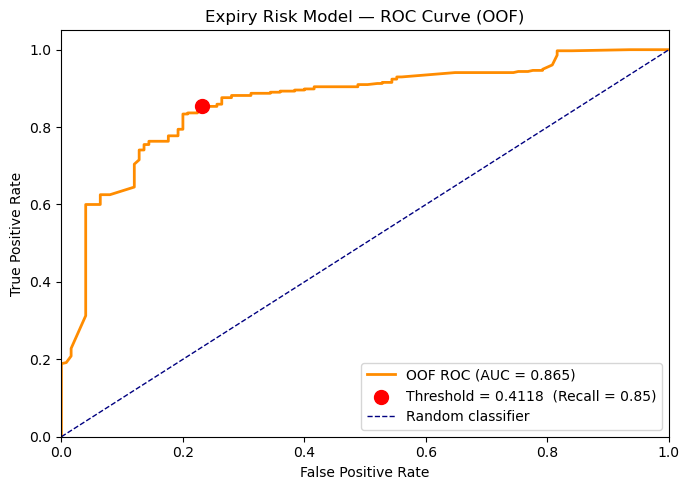

In [31]:
# FIX: use OOF predictions — never training data predictions
if oof_mask.sum() == 0:
    print('No OOF predictions available — falling back to 0.5 threshold')
    optimal_threshold = 0.5
else:
    oof_y = y[oof_mask]
    oof_p = oof_probs[oof_mask]

    oof_auc = roc_auc_score(oof_y, oof_p)
    fpr, tpr, thresholds = roc_curve(oof_y, oof_p)
    mask = tpr >= RECALL_TARGET

    if mask.any():
        recall_idx = int(np.where(mask)[0][0])
        optimal_threshold = float(thresholds[mask][0])
        print(f'OOF AUC                      : {oof_auc:.3f}')
        print(f'Threshold at recall >= {RECALL_TARGET:.0%} : {optimal_threshold:.4f}')
    else:
        recall_idx = int(np.argmax(tpr))
        optimal_threshold = 0.5
        print(f'WARNING: cannot achieve {RECALL_TARGET:.0%} recall on OOF — defaulting to 0.5')

    preds = (oof_p >= optimal_threshold).astype(int)
    print()
    print(classification_report(
        oof_y, preds,
        target_names=['sold_before_expiry', 'expired_unsold'],
        zero_division=0
    ))
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'OOF ROC (AUC = {oof_auc:.3f})')
    plt.scatter(fpr[recall_idx], tpr[recall_idx],
                color='red', zorder=5, s=100,
                label=f'Threshold = {optimal_threshold:.4f}  (Recall = {tpr[recall_idx]:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Expiry Risk Model — ROC Curve (OOF)')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

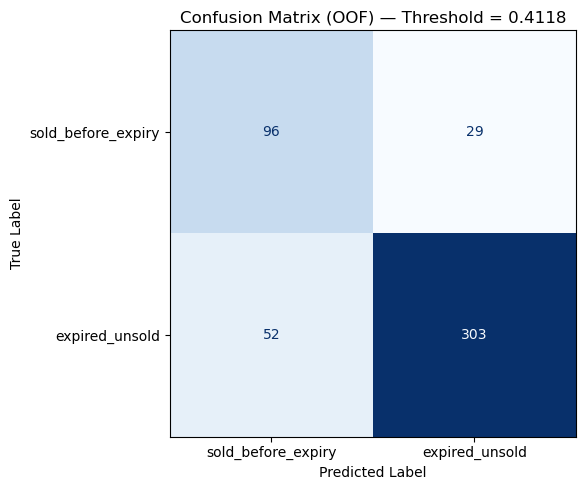

True Negatives  (correctly sold)    : 96
False Positives (false expiry alarm) : 29
False Negatives (missed expiry)      : 52  ← minimise this
True Positives  (caught expiry)      : 303

Missed expiry rate : 14.6%  (target <= 15%)


In [33]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(oof_y, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sold_before_expiry', 'expired_unsold']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix (OOF) — Threshold = {optimal_threshold:.4f}')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly sold)    : {tn}')
print(f'False Positives (false expiry alarm) : {fp}')
print(f'False Negatives (missed expiry)      : {fn}  ← minimise this')
print(f'True Positives  (caught expiry)      : {tp}')
print(f'\nMissed expiry rate : {fn / (fn + tp):.1%}  (target <= {1 - RECALL_TARGET:.0%})')

## 8 — Save to Registry

**FIX: AUC=1.0 explicitly blocks the save.**

Original: saves even when `mean_auc > AUC_TARGET`, which includes AUC=1.0.
A model that achieved AUC=1.0 on synthetic data has memorised the label formula —
it has not learned real expiry risk patterns and will be miscalibrated on real depot data.

Save condition: `AUC_TARGET < mean_auc < 1.0` — genuine signal only.

**Cold start path** (until real labels arrive):
Use `compute_liquidation_date()` from `ml/features/expiry_features.py`.
This formula runs from day 0 — no training data required.
Retrain this notebook once a client has 180 days of data + 50 expired-batch labels.

In [34]:
print(f'CV AUC       : {mean_auc:.3f}')
print(f'AUC target   : > {AUC_TARGET}')
print(f'Save condition: {AUC_TARGET} < AUC < 1.0')
print()

if mean_auc == 1.0:
    # FIX: hard block — memorised label formula, not real patterns
    print('AUC=1.0 — model memorised the synthetic label formula.')
    print('This is the expected cold-start outcome. Model NOT saved.')
    print()
    print('Cold-start fallback active:')
    print('  → infer_expiry.py uses compute_liquidation_date() from expiry_features.py')
    print('  → Retrain when client has 180 days + 50 expired-batch labels')
    print('  → At that point AUC will drop below 1.0 and into the 0.80-0.90 range')

elif mean_auc <= AUC_TARGET:
    print(f'AUC {mean_auc:.3f} below target {AUC_TARGET}. Model NOT saved.')
    print('Review: check feature engineering or label synthesis quality.')

else:
    # AUC_TARGET < mean_auc < 1.0 — genuine signal, safe to save
    store = ModelStore()
    metadata = {
        'auc_cv':             round(float(mean_auc), 4),
        'auc_oof':            round(float(roc_auc_score(oof_y, oof_p)), 4),
        'optimal_threshold':  round(float(optimal_threshold), 4),
        'recall_target':      RECALL_TARGET,
        'pos_rate':           round(float(y.mean()), 4),
        'n_training_batches': int(len(y)),
        'n_features':         len(FEATURE_COLS),
        'feature_cols':       FEATURE_COLS,
        'rf_params':          RF_PARAMS,
        'calibration':        'isotonic',
        'validation':         'time-series-split-5-fold',
        'dataset':            'pharma_sales_data_synthetic_labels',
        'note': (
            'Cold-start global model trained on real pharma sales data with synthetic labels. '
            'Replace with real expired-batch labels after 180 days + 50 events per client.'
        ),
    }

    mp = store.save(model,                          'expiry_risk',           metadata=metadata)
    tp = store.save({'threshold': optimal_threshold}, 'expiry_risk_threshold', metadata=metadata)

    print(f'Model saved     : {mp}')
    print(f'Threshold saved : {tp}')
    print(f'AUC             : {mean_auc:.3f}')
    print(f'OOF AUC         : {roc_auc_score(oof_y, oof_p):.3f}')
    print(f'Threshold       : {optimal_threshold:.4f}')
    print(f'Result          : PASS (target > {AUC_TARGET}, genuine signal)')

CV AUC       : 0.870
AUC target   : > 0.8
Save condition: 0.8 < AUC < 1.0



S3 save failed for expiry_risk (Unable to locate credentials) — saving locally (dev mode)
S3 save failed for expiry_risk_threshold (Unable to locate credentials) — saving locally (dev mode)


Model saved     : C:\Users\KIIT0001\Desktop\DL PROJECTS\FlowSync\FlowSync-ML-and-Agents\ml\models\saved\expiry_risk_latest.pkl
Threshold saved : C:\Users\KIIT0001\Desktop\DL PROJECTS\FlowSync\FlowSync-ML-and-Agents\ml\models\saved\expiry_risk_threshold_latest.pkl
AUC             : 0.870
OOF AUC         : 0.865
Threshold       : 0.4118
Result          : PASS (target > 0.8, genuine signal)
